Mounted at /content/drive


✅ Model loaded successfully
📁 Found 2 images in: /content/drive/MyDrive/ML_WSSV/WSSV/images


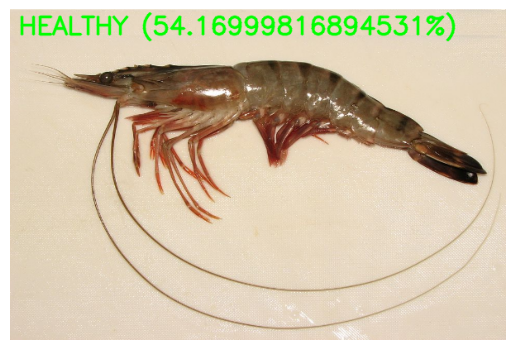

🖼️ Test_Image2.jpg → HEALTHY (54.16999816894531% confidence)


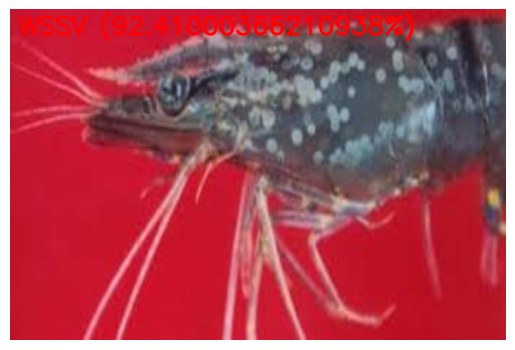

🖼️ Test_Image1.jpeg → WSSV (92.41000366210938% confidence)

📤 You can now upload an image from your computer to test


Saving shrimp.jpg to shrimp.jpg
📥 Uploaded file: shrimp.jpg


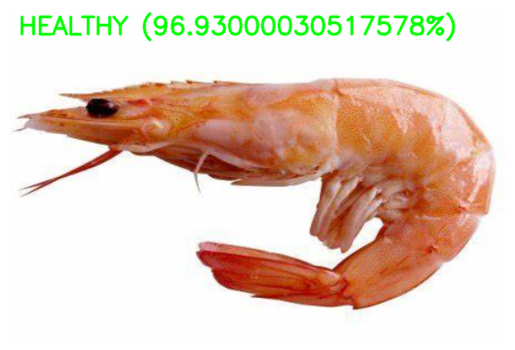

🖼️ shrimp.jpg → HEALTHY (96.93000030517578% confidence)


In [ ]:
# =========================================================
# Mount Google Drive
# =========================================================

# Import Google Drive interface from Google Colab
# This allows the notebook to access files stored in your Google Drive
from google.colab import drive

# Connect Google Drive to the Colab environment
# After this step, the program can read datasets and trained models from Drive
drive.mount('/content/drive')


# =========================================================
# Import Required Libraries
# =========================================================

# OS library helps work with folders and file paths
import os

# NumPy is used for numerical operations and handling image arrays
import numpy as np

# Glob helps find files in folders using patterns such as *.jpg or *.png
import glob

# OpenCV library used for image processing and drawing labels on images
import cv2

# Matplotlib library used to display images and graphs
import matplotlib.pyplot as plt

# Load the trained deep learning model
from tensorflow.keras.models import load_model

# Image utilities used to load and convert images into arrays
from tensorflow.keras.preprocessing import image

# TensorFlow deep learning framework
import tensorflow as tf

# Import Swish activation function used in the CrustaScope model
# This must be provided when loading the model
from tensorflow.keras.activations import swish


# =========================================================
# Load Trained CrustaScope Model
# =========================================================

# Path where the trained CrustaScope model is stored in Google Drive
model_path = '/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/CrustaScope_model.h5'

# Folder containing shrimp images for testing
test_images_path = '/content/drive/MyDrive/ML_WSSV/WSSV/images'

# Load the trained model
# custom_objects tells TensorFlow to use the Swish activation function
model = load_model(model_path, custom_objects={"swish": swish})

# Display confirmation message
print("✅ Model loaded successfully")


# =========================================================
# Prediction Function
# =========================================================

# This function:
# 1. Loads a shrimp image
# 2. Preprocesses it
# 3. Runs the AI model
# 4. Displays the prediction on the image

def predict_and_display(img_path):

    # Load image and resize to 224x224 (required input size for the model)
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert image into numeric array
    img_array = image.img_to_array(img) / 255.0

    # Normalize pixel values from range 0–255 to 0–1
    # This improves prediction stability

    # Expand dimensions so the model sees the image as a batch
    img_array = np.expand_dims(img_array, axis=0)

    # Run prediction using the trained model
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Determine predicted class
    label = 'WSSV' if prediction > 0.5 else 'HEALTHY'

    # Calculate prediction confidence
    confidence = prediction if prediction > 0.5 else 1 - prediction


    # =========================================================
    # Display Image with Prediction Label
    # =========================================================

    # Read image using OpenCV
    img_cv = cv2.imread(img_path)

    # Resize image for better display
    img_cv = cv2.resize(img_cv, (600, 400))

    # Choose color depending on prediction
    # Green = Healthy
    # Red = WSSV infected
    color = (0, 255, 0) if label == 'HEALTHY' else (0, 0, 255)

    # Create text label showing prediction and confidence
    text = f"{label} ({round(confidence*100, 2)}%)"

    # Draw prediction text on the image
    cv2.putText(img_cv, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

    # Convert image from OpenCV BGR format to RGB format for matplotlib
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(img_rgb)

    # Remove axis numbers
    plt.axis('off')

    # Show the image
    plt.show()

    # Print prediction result in console
    print(f"🖼️ {os.path.basename(img_path)} → {label} ({round(confidence*100, 2)}% confidence)")


# =========================================================
# Predict Images Stored in Google Drive
# =========================================================

# Define supported image file types
extensions = ['*.jpg', '*.jpeg', '*.png']

# List to store all detected images
all_images = []

# Search for images with each extension
for ext in extensions:
    all_images.extend(glob.glob(os.path.join(test_images_path, ext)))

# Print number of images found
print(f"📁 Found {len(all_images)} images in: {test_images_path}")

# Run prediction for every image in the folder
for img_path in all_images:
    try:
        predict_and_display(img_path)
    except Exception as e:
        print(f"❌ Error with {img_path}: {e}")


# =========================================================
# Upload New Image from Local Computer
# =========================================================

# Import file upload tool from Google Colab
from google.colab import files

# Inform the user they can upload an image
print("\n📤 You can now upload an image from your computer to test")

# Open file upload dialog
uploaded = files.upload()

# Loop through uploaded files
for filename in uploaded.keys():

    print(f"📥 Uploaded file: {filename}")

    try:
        # Run prediction on uploaded image
        predict_and_display(filename)

    except Exception as e:
        print(f"❌ Error with uploaded image: {e}")

Mounted at /content/drive


✅ Model loaded successfully
📁 Found 2 images in: /content/drive/MyDrive/ML_WSSV/WSSV/images


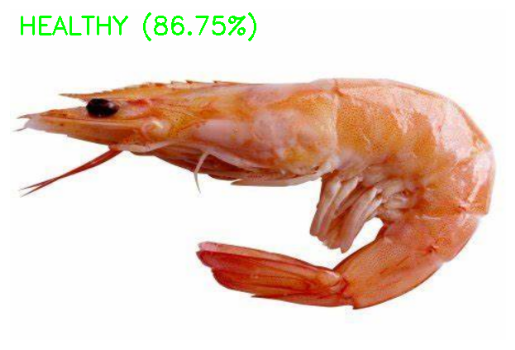

🖼️ Test_Image2.jpg → HEALTHY (86.75% confidence)


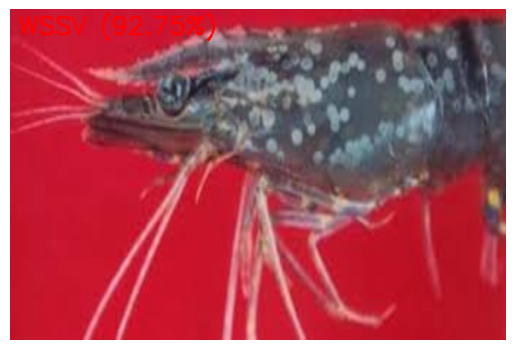

🖼️ Test_Image1.jpeg → WSSV (92.75% confidence)

📤 Upload an image for prediction


Saving wssv1.jpeg to wssv1.jpeg
📥 Uploaded file: wssv1.jpeg


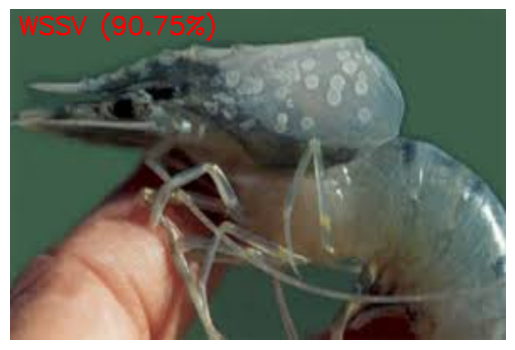

🖼️ wssv1.jpeg → WSSV (90.75% confidence)

📸 Webcam mode is loading...
▶️ Starting REAL-TIME WSSV DETECTION...


In [ ]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================

# Import Google Drive interface from Google Colab
# This allows the notebook to access files stored in your Google Drive
from google.colab import drive

# Connect Google Drive to the notebook environment
# After mounting, datasets and trained models can be accessed as normal folders
drive.mount('/content/drive')


# ================================
# 2. IMPORTS
# ================================

# OS library helps manage folders and file paths
import os

# Glob library searches for files in folders using patterns such as *.jpg
import glob

# NumPy is used for numerical operations and image array processing
import numpy as np

# OpenCV is used for image processing, drawing text, and working with webcam frames
import cv2

# Matplotlib is used to display images and graphs inside the notebook
import matplotlib.pyplot as plt

# Load a trained neural network model
from tensorflow.keras.models import load_model

# Image preprocessing utilities for loading and converting images
from tensorflow.keras.preprocessing import image

# Import Swish activation function used in the CrustaScope neural network
from tensorflow.keras.activations import swish

# TensorFlow deep learning framework
import tensorflow as tf


# ================================
# 3. LOAD TRAINED MODEL
# ================================

# Path to the trained CrustaScope model stored in Google Drive
model_path = '/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/CrustaScope_model.h5'

# Folder containing shrimp images used for testing
test_images_path = '/content/drive/MyDrive/ML_WSSV/WSSV/images'

# Load the trained model
# custom_objects is required because the model uses the Swish activation function
model = load_model(model_path, custom_objects={"swish": swish})

# Print confirmation message
print("✅ Model loaded successfully")


# ================================
# 4. PREDICTION FUNCTION (IMAGE FILES)
# ================================

# This function loads a shrimp image, runs the AI model, and displays the result
def predict_and_display(img_path):

    # Load the image and resize to 224x224 pixels (model input size)
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert image into a numeric array and normalize pixel values
    img_array = image.img_to_array(img) / 255.0

    # Expand dimensions so the model sees the image as a batch
    img_array = np.expand_dims(img_array, axis=0)

    # Run prediction using the trained model
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Determine predicted class
    label = 'WSSV' if prediction > 0.5 else 'HEALTHY'

    # Calculate confidence level of prediction
    confidence = prediction if prediction > 0.5 else 1 - prediction


    # Display image with prediction label
    img_cv = cv2.imread(img_path)

    # Resize image for clearer display
    img_cv = cv2.resize(img_cv, (600, 400))

    # Choose text color depending on prediction
    # Green = Healthy shrimp
    # Red = WSSV infected shrimp
    color = (0, 255, 0) if label == 'HEALTHY' else (0, 0, 255)

    # Create label text with confidence percentage
    text = f"{label} ({round(confidence*100, 2)}%)"

    # Draw the prediction text on the image
    cv2.putText(img_cv, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # Convert OpenCV image format from BGR to RGB for proper display
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    # Show the image in the notebook
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    # Print prediction result in console
    print(f"🖼️ {os.path.basename(img_path)} → {label} ({round(confidence*100, 2)}% confidence)")


# ================================
# 5. RUN PREDICTION ON DRIVE IMAGES
# ================================

# Supported image formats
extensions = ['*.jpg', '*.jpeg', '*.png']

# List to store all detected images
all_images = []

# Search the image folder for all supported image files
for ext in extensions:
    all_images.extend(glob.glob(os.path.join(test_images_path, ext)))

# Print number of images found
print(f"📁 Found {len(all_images)} images in: {test_images_path}")

# Run prediction on each image
for img_path in all_images:
    try:
        predict_and_display(img_path)
    except Exception as e:
        print(f"❌ Error with {img_path}: {e}")


# ================================
# 6. UPLOAD IMAGE FROM LOCAL SYSTEM
# ================================

# Import upload utility for Google Colab
from google.colab import files

# Inform the user that they can upload a new image
print("\n📤 Upload an image for prediction")

# Open file upload dialog
uploaded = files.upload()

# Run prediction on uploaded images
for filename in uploaded.keys():
    print(f"📥 Uploaded file: {filename}")
    try:
        predict_and_display(filename)
    except Exception as e:
        print(f"❌ Error with uploaded image: {e}")


# ================================================================
# 7. REAL-TIME WEBCAM WSSV DETECTION (GOOGLE COLAB)
# ================================================================

# Import JavaScript execution tools used for webcam streaming
from google.colab.output import eval_js

# Libraries used for encoding/decoding images between Python and JavaScript
from base64 import b64decode, b64encode

# Used to display HTML/JavaScript inside the notebook
from IPython.display import HTML, display

print("\n📸 Webcam mode is loading...")


# ================================
# PREPROCESS A FRAME
# ================================

# Prepare a webcam frame before feeding it to the AI model
def preprocess_frame(frame):

    # Resize frame to model input size
    img = cv2.resize(frame, (224, 224))

    # Normalize pixel values
    img = img.astype("float32") / 255.0

    # Convert into batch format
    img = np.expand_dims(img, axis=0)

    return img


# ================================
# DRAW LABEL ON FRAME
# ================================

# Overlay prediction label on webcam frame
def draw_label(frame, label, confidence):

    # Green = Healthy, Red = WSSV
    color = (0, 255, 0) if label == "HEALTHY" else (0, 0, 255)

    # Create label text
    text = f"{label} ({round(confidence*100, 1)}%)"

    # Draw text on frame
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                1, color, 2, cv2.LINE_AA)

    return frame


# ================================
# PREDICT A SINGLE FRAME
# ================================

# Run AI prediction on a webcam frame
def predict_frame(frame):

    # Preprocess frame
    x = preprocess_frame(frame)

    # Get model prediction
    pred = model.predict(x, verbose=0)[0][0]

    # Determine predicted label
    label = "WSSV" if pred > 0.5 else "HEALTHY"

    # Calculate prediction confidence
    confidence = pred if pred > 0.5 else (1 - pred)

    return label, confidence


# ================================
# PYTHON CALLBACK — PROCESS ONE FRAME
# ================================

# This function receives webcam frames from JavaScript
# processes them using the AI model, and sends back labeled frames
def process_js_frame(data_url):

    # Decode image from base64 format
    header, encoded = data_url.split(',', 1)
    img = b64decode(encoded)

    # Convert bytes into OpenCV image
    arr = np.frombuffer(img, dtype=np.uint8)
    frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    # Run AI prediction
    label, confidence = predict_frame(frame)

    # Draw prediction label on frame
    frame = draw_label(frame, label, confidence)

    # Encode frame back to JPEG format
    _, jpeg = cv2.imencode('.jpg', frame)

    # Convert image to base64 to send back to browser
    b64 = b64encode(jpeg).decode('utf-8')

    return {"frame": b64}


# Register Python callback so JavaScript can call it
from google.colab import output
output.register_callback('process_frame', process_js_frame)


# ================================
# JAVASCRIPT TO STREAM WEBCAM
# ================================

# This function launches webcam streaming inside the notebook
def start_webcam():

    js = """
    async function main() {
      const video = document.createElement('video');
      video.style.width = '640px';
      video.style.height = '480px';
      document.body.appendChild(video);

      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      document.body.appendChild(canvas);
      const ctx = canvas.getContext('2d');

      while (true) {
        ctx.drawImage(video, 0, 0);
        await new Promise(r => requestAnimationFrame(r));

        const imgData = canvas.toDataURL('image/jpeg', 0.8);
        const response = await google.colab.kernel.invokeFunction(
          'process_frame', [imgData], {});
      }
    }
    main();
    """

    # Display JavaScript inside notebook
    display(HTML(f"<script>{js}</script>"))


# Start real-time webcam detection
print("▶️ Starting REAL-TIME WSSV DETECTION...")
start_webcam()